In [4]:
import sys
sys.path.insert(0, '..')

from utils.evaluation import (
    load_and_evaluate_model
)
import pandas as pd
from utils.preprocessing import (
    FEATURES
)

In [2]:
# =========================
# Define datasets
# =========================
df_cicids_combined = pd.read_csv("../data/cicids_combined_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023 = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")

In [6]:
MODEL_TYPES = ["mlp", "cnnlstm"]
DATASETS = {
    "cicids_combined": {"X": df_cicids_combined[FEATURES], "y": df_cicids_combined["label"]},
    "ciciot2023": {"X": df_ciciot2023[FEATURES], "y": df_ciciot2023["label"]},
}


EVALUATING CICIDS_COMBINED-MLP ON CICIOT2023

=== CICIDS_COMBINED-MLP TESTED ON CICIOT2023 Classification Report ===

                precision    recall  f1-score   support

        ATTACK     0.0433    0.0336    0.0378   1187082
        BENIGN     0.3587    0.8591    0.5061    342255
DDOS_SYN_FLOOD     0.0000    0.0000    0.0000    741270
DDOS_UDP_FLOOD     0.0075    0.0020    0.0031    290106
DOS_HTTP_FLOOD     0.3236    0.0130    0.0249   1508589
      PORTSCAN     0.0704    0.7794    0.1292    216533

      accuracy                         0.1220   4285835
     macro avg     0.1339    0.2812    0.1169   4285835
  weighted avg     0.1586    0.1220    0.0664   4285835

Overall Accuracy: 0.1220

=== Per-Label Accuracy ===

ATTACK: 0.0336
BENIGN: 0.8591
DDOS_SYN_FLOOD: 0.0000
DDOS_UDP_FLOOD: 0.0020
DOS_HTTP_FLOOD: 0.0130
PORTSCAN: 0.7794


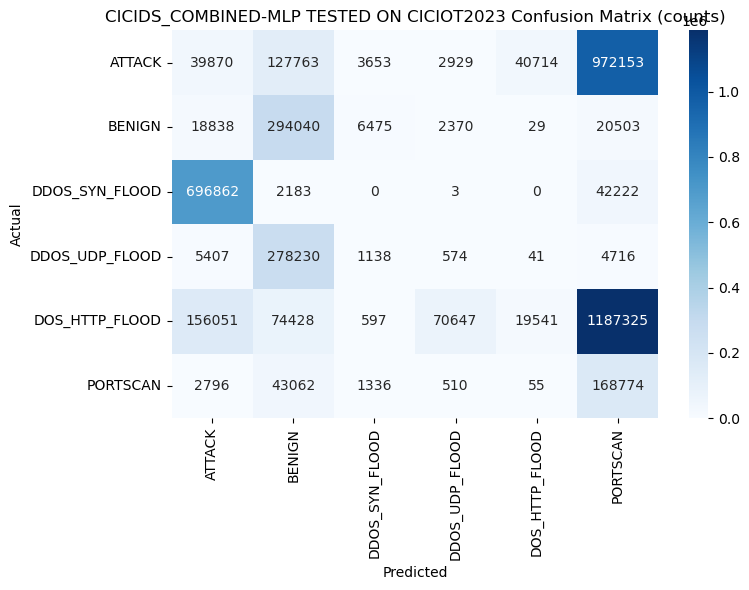


EVALUATING CICIOT2023-MLP ON CICIDS2017

=== CICIOT2023-MLP TESTED ON CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        ATTACK     0.5185    0.9853    0.6795   8869735
        BENIGN     0.8975    0.0196    0.0383   2566701
DDOS_SYN_FLOOD     0.0000    0.0000    0.0000   4337456
DDOS_UDP_FLOOD     0.0081    0.0002    0.0004   1316249
DOS_HTTP_FLOOD     0.5300    0.8767    0.6606    154769
      PORTSCAN     0.7872    0.9949    0.8790    154034

      accuracy                         0.5218  17398944
     macro avg     0.4569    0.4794    0.3763  17398944
  weighted avg     0.4090    0.5218    0.3657  17398944

Overall Accuracy: 0.5218

=== Per-Label Accuracy ===

ATTACK: 0.9853
BENIGN: 0.0196
DDOS_SYN_FLOOD: 0.0000
DDOS_UDP_FLOOD: 0.0002
DOS_HTTP_FLOOD: 0.8767
PORTSCAN: 0.9949


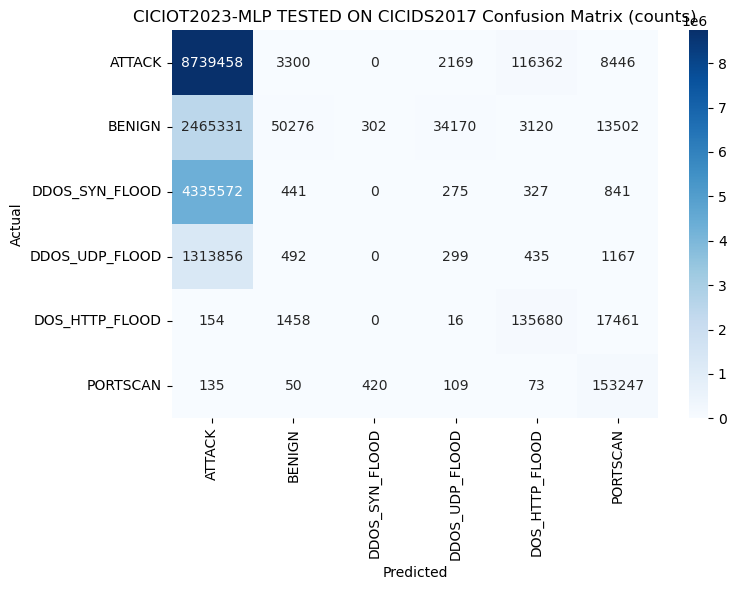


EVALUATING CICIDS_COMBINED-CNNLSTM ON CICIOT2023

=== CICIDS_COMBINED-CNNLSTM TESTED ON CICIOT2023 Classification Report ===

                precision    recall  f1-score   support

        ATTACK     0.1390    0.1059    0.1202   1187082
        BENIGN     0.1323    0.8407    0.2286    342255
DDOS_SYN_FLOOD     0.0000    0.0000    0.0000    741270
DDOS_UDP_FLOOD     0.1040    0.0118    0.0211    290106
DOS_HTTP_FLOOD     0.9508    0.0237    0.0462   1508589
      PORTSCAN     0.2719    0.7293    0.3961    216533

      accuracy                         0.1424   4285835
     macro avg     0.2663    0.2852    0.1354   4285835
  weighted avg     0.4045    0.1424    0.0892   4285835

Overall Accuracy: 0.1424

=== Per-Label Accuracy ===

ATTACK: 0.1059
BENIGN: 0.8407
DDOS_SYN_FLOOD: 0.0000
DDOS_UDP_FLOOD: 0.0118
DOS_HTTP_FLOOD: 0.0237
PORTSCAN: 0.7293


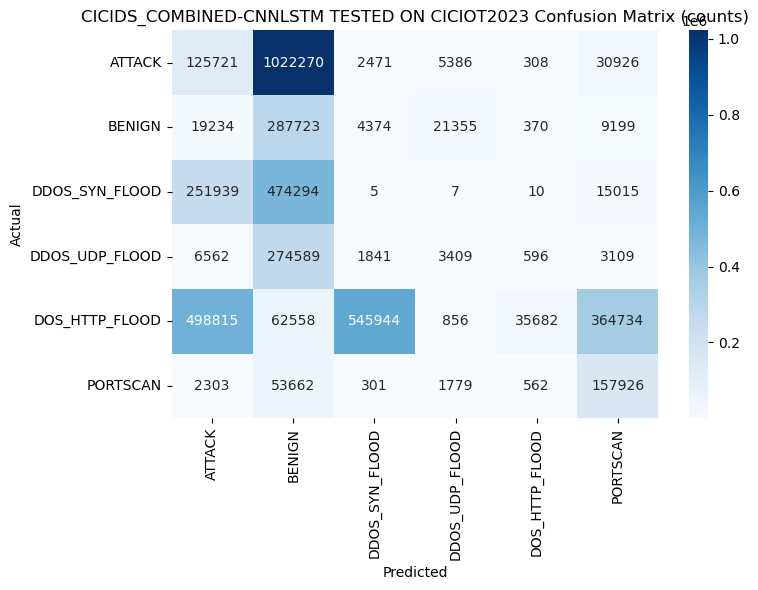


EVALUATING CICIOT2023-CNNLSTM ON CICIDS2017

=== CICIOT2023-CNNLSTM TESTED ON CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        ATTACK     0.4456    0.6359    0.5240   8869735
        BENIGN     0.9676    0.0179    0.0352   2566701
DDOS_SYN_FLOOD     0.0910    0.0635    0.0748   4337456
DDOS_UDP_FLOOD     0.0544    0.0054    0.0097   1316249
DOS_HTTP_FLOOD     0.5624    0.9751    0.7134    154769
      PORTSCAN     0.1210    0.9978    0.2159    154034

      accuracy                         0.3605  17398944
     macro avg     0.3737    0.4493    0.2622  17398944
  weighted avg     0.4028    0.3605    0.3000  17398944

Overall Accuracy: 0.3605

=== Per-Label Accuracy ===

ATTACK: 0.6359
BENIGN: 0.0179
DDOS_SYN_FLOOD: 0.0635
DDOS_UDP_FLOOD: 0.0054
DOS_HTTP_FLOOD: 0.9751
PORTSCAN: 0.9978


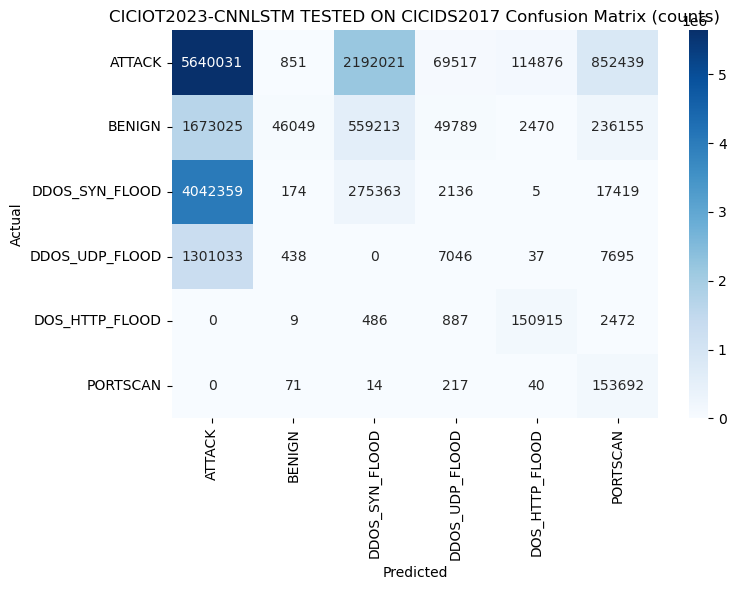

In [7]:
for MODEL_TYPE in MODEL_TYPES:
    for dataset_name, dataset_config in DATASETS.items():
        if dataset_name == "cicids_combined":
            X_test = DATASETS["ciciot2023"]["X"]
            y_test = DATASETS["ciciot2023"]["y"]
            test_name = "CICIOT2023"
        else:
            X_test = DATASETS["cicids_combined"]["X"]
            y_test = DATASETS["cicids_combined"]["y"]
            test_name = "CICIDS2017"
        print("\n" + "=" * 70)
        print(f"EVALUATING {dataset_name.upper()}-{MODEL_TYPE.upper()} ON {test_name}")
        print("=" * 70)
        joblib_path = f"models/{MODEL_TYPE}_property_{dataset_name}.joblib"
        load_and_evaluate_model(
            joblib_path=joblib_path,
            X=X_test,
            y_true=y_test,
            model_name=f"{dataset_name.upper()}-{MODEL_TYPE.upper()} TESTED ON {test_name}",
            batch_size=1024
        )